In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
import numpy as np
from pybaseball import statcast, playerid_reverse_lookup
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

GAME_DATE = '2026-05-16'
OPPONENT = 'DET'
RESULT = 'W 2-1'
STARTER_NAME = 'Fluharty, Mason'
BULK_NAME = 'Miles, Spencer'
HOME_AWAY = 'AWAY'

SEASON_W = 20
SEASON_L = 25
SEASON_RS = 0
SEASON_RA = 0

PITCH_COLORS = {
    'FF': '#e74c3c', 'SL': '#3498db', 'CH': '#2ecc71',
    'CU': '#f39c12', 'SI': '#1abc9c', 'FC': '#95a5a6',
    'ST': '#9b59b6', 'KC': '#e67e22', 'FS': '#34495e',
    'SV': '#8e44ad', 'KN': '#7f8c8d'
}
PITCH_NAMES = {
    'FF': '4-Seam', 'SL': 'Slider', 'CH': 'Changeup',
    'CU': 'Curveball', 'SI': 'Sinker', 'FC': 'Cutter',
    'ST': 'Sweeper', 'KC': 'K-Curve', 'FS': 'Splitter',
    'SV': 'Slurve', 'KN': 'Knuckle'
}

print(f"=== Blue Jays Game Report v2.0: {GAME_DATE} vs {OPPONENT} ({RESULT}) ===")
print(f"Season Record: {SEASON_W}-{SEASON_L}")
print(f"Bullpen Day: {STARTER_NAME} (opener) + {BULK_NAME} (bulk)")

=== Blue Jays Game Report v2.0: 2026-05-16 vs DET (W 2-1) ===
Season Record: 20-25
Bullpen Day: Fluharty, Mason (opener) + Miles, Spencer (bulk)


In [2]:
game_data = statcast(start_dt=GAME_DATE, end_dt=GAME_DATE)

if 'TOR' in game_data['home_team'].values:
    jays_pitching = game_data[game_data['home_team'] == 'TOR']
    jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
    jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']
    print("Blue Jays: HOME")
else:
    jays_pitching = game_data[game_data['away_team'] == 'TOR']
    jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']
    jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
    print("Blue Jays: AWAY")

print(f"Total pitches in game: {len(game_data)}")
print(f"Blue Jays pitching data: {len(jays_pitchers)} pitches")
print(f"Blue Jays batting data: {len(jays_batting)} pitches")

opener = jays_pitchers[jays_pitchers['player_name'] == STARTER_NAME]
bulk = jays_pitchers[jays_pitchers['player_name'] == BULK_NAME]
print(f"\n{STARTER_NAME} (opener): {len(opener)} pitches")
print(f"{BULK_NAME} (bulk): {len(bulk)} pitches")

starter = pd.concat([opener, bulk])
print(f"Combined analysis: {len(starter)} pitches")

This is a large query, it may take a moment to complete


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.71it/s]

Blue Jays: AWAY
Total pitches in game: 4328
Blue Jays pitching data: 152 pitches
Blue Jays batting data: 115 pitches

Fluharty, Mason (opener): 19 pitches
Miles, Spencer (bulk): 56 pitches
Combined analysis: 75 pitches


In [3]:
for pitcher_name, pitcher_data in [(STARTER_NAME, opener), (BULK_NAME, bulk)]:
    if len(pitcher_data) == 0:
        continue

    print(f"\n{'='*60}")
    print(f"  {pitcher_name} — Pitch Arsenal Performance ({len(pitcher_data)} pitches)")
    print(f"{'='*60}")

    print(f"{'Pitch':<12} {'#':>4} {'Usage':>7} {'Velo':>7} {'Whiff%':>8} {'CSW%':>7} {'Chase%':>8} {'Grade':>6}")
    print("-" * 65)

    for pt in pitcher_data['pitch_type'].value_counts().index:
        pt_data = pitcher_data[pitcher_data['pitch_type'] == pt]
        count = len(pt_data)
        usage = count / len(pitcher_data) * 100
        avg_velo = pt_data['release_speed'].mean()

        swinging = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
        swings = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                               'foul', 'foul_tip', 'hit_into_play',
                                               'hit_into_play_no_out', 'hit_into_play_score']).sum()
        whiff_rate = (swinging / swings * 100) if swings > 0 else 0

        called = (pt_data['description'] == 'called_strike').sum()
        csw = (swinging + called) / count * 100

        outside_zone = pt_data[(pt_data['plate_x'].abs() > 0.83) |
                               (pt_data['plate_z'] < 1.5) |
                               (pt_data['plate_z'] > 3.5)]
        chases = outside_zone['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                    'foul', 'foul_tip', 'hit_into_play',
                                                    'hit_into_play_no_out', 'hit_into_play_score']).sum()
        chase_rate = (chases / len(outside_zone) * 100) if len(outside_zone) > 0 else 0

        if whiff_rate >= 30: grade = '🟢 A'
        elif whiff_rate >= 20: grade = '🟢 B'
        elif whiff_rate >= 12: grade = '🟡 C'
        else: grade = '🔴 D'

        print(f"{PITCH_NAMES.get(pt, pt):<12} {count:>4} {usage:>6.1f}% {avg_velo:>6.1f} {whiff_rate:>7.1f}% {csw:>6.1f}% {chase_rate:>7.1f}%  {grade}")


  Fluharty, Mason — Pitch Arsenal Performance (19 pitches)
Pitch           #   Usage    Velo   Whiff%    CSW%   Chase%  Grade
-----------------------------------------------------------------
Cutter         10   52.6%   89.1     0.0%   30.0%    33.3%  🔴 D
Sweeper         5   26.3%   80.7    75.0%   80.0%   100.0%  🟢 A
Changeup        3   15.8%   84.7   100.0%   33.3%    33.3%  🟢 A

  Miles, Spencer — Pitch Arsenal Performance (56 pitches)
Pitch           #   Usage    Velo   Whiff%    CSW%   Chase%  Grade
-----------------------------------------------------------------
Curveball      20   35.7%   80.3    41.7%   45.0%    50.0%  🟢 A
Sinker         20   35.7%   95.7    37.5%   30.0%     0.0%  🟢 A
4-Seam          8   14.3%   95.2     0.0%   12.5%    33.3%  🔴 D
Slider          7   12.5%   85.8    66.7%   28.6%     0.0%  🟢 A
Changeup        1    1.8%   86.2     0.0%    0.0%     0.0%  🔴 D


In [4]:
for pitcher_name, pitcher_data in [(STARTER_NAME, opener), (BULK_NAME, bulk)]:
    if len(pitcher_data) == 0:
        continue
    print(f"\n=== {pitcher_name} — Pitch Movement (inches) ===")
    movement = pitcher_data.groupby('pitch_type').agg(
        h_break=('pfx_x', lambda x: x.mean() * 12),
        v_break=('pfx_z', lambda x: x.mean() * 12),
        count=('pitch_type', 'count')
    ).round(1)
    movement = movement[movement['count'] >= 2]
    print(movement)


=== Fluharty, Mason — Pitch Movement (inches) ===
            h_break  v_break  count
pitch_type                         
CH             11.3      5.3      3
FC             -2.8     11.3     10
ST            -15.0      1.1      5

=== Miles, Spencer — Pitch Movement (inches) ===
            h_break  v_break  count
pitch_type                         
CU             13.0    -11.2     20
FF             -8.1     14.1      8
SI            -16.0      6.5     20
SL              4.7     -1.3      7


Chart saved!


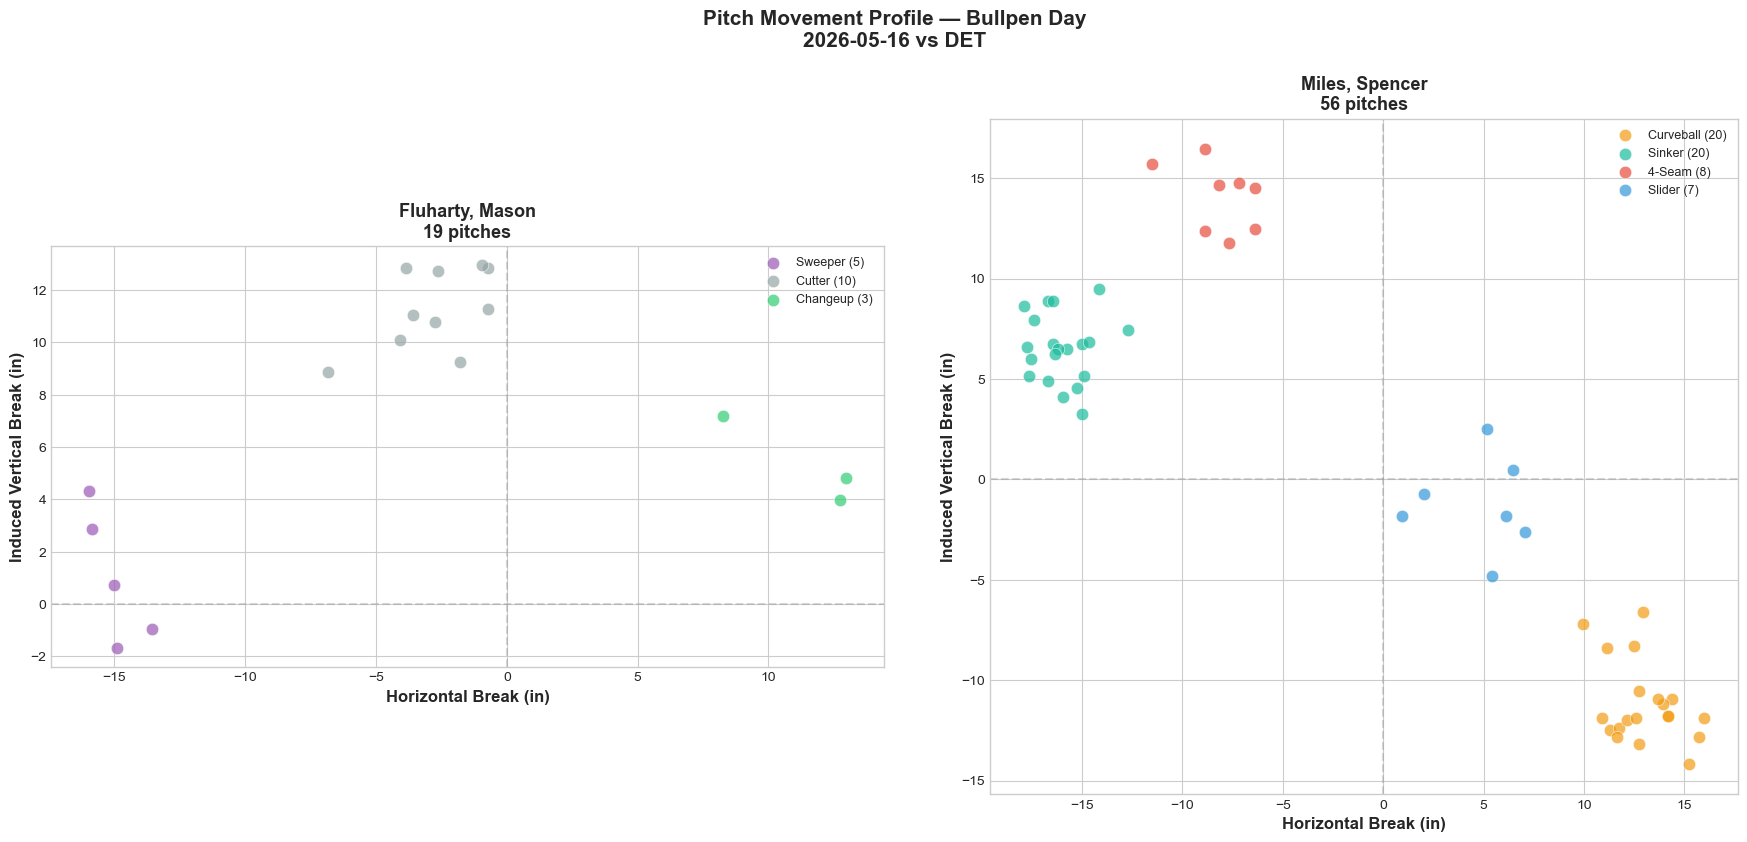

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, (pitcher_name, pitcher_data) in enumerate([(STARTER_NAME, opener), (BULK_NAME, bulk)]):
    ax = axes[idx]
    if len(pitcher_data) == 0:
        ax.set_title(f'{pitcher_name}\nNo data', fontsize=13)
        continue

    for pt in pitcher_data['pitch_type'].unique():
        data = pitcher_data[pitcher_data['pitch_type'] == pt].dropna(subset=['pfx_x', 'pfx_z'])
        if len(data) >= 2:
            ax.scatter(data['pfx_x'] * 12, data['pfx_z'] * 12,
                       c=PITCH_COLORS.get(pt, '#95a5a6'), s=80, alpha=0.7,
                       label=f"{PITCH_NAMES.get(pt, pt)} ({len(data)})",
                       edgecolors='white', linewidth=0.5)

    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('Horizontal Break (in)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Induced Vertical Break (in)', fontsize=12, fontweight='bold')
    ax.set_title(f'{pitcher_name}\n{len(pitcher_data)} pitches', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

plt.suptitle(f'Pitch Movement Profile — Bullpen Day\n{GAME_DATE} vs {OPPONENT}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../visualizations/movement_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [6]:
for pitcher_name, pitcher_data in [(STARTER_NAME, opener), (BULK_NAME, bulk)]:
    if len(pitcher_data) == 0:
        continue
    print(f"\n=== {pitcher_name} vs LHB/RHB ===")
    lr_split = pitcher_data.groupby('stand').agg(
        pitches=('pitch_type', 'count'),
        avg_velo=('release_speed', 'mean'),
        swinging_strikes=('description', lambda x: (x.isin(['swinging_strike', 'swinging_strike_blocked'])).sum())
    ).round(1)
    lr_split['whiff_per_pitch'] = (lr_split['swinging_strikes'] / lr_split['pitches'] * 100).round(1)
    print(lr_split)


=== Fluharty, Mason vs LHB/RHB ===
       pitches  avg_velo  swinging_strikes  whiff_per_pitch
stand                                                      
L            5      83.6                 2             40.0
R           13      86.9                 2             15.4

=== Miles, Spencer vs LHB/RHB ===
       pitches  avg_velo  swinging_strikes  whiff_per_pitch
stand                                                      
L           30      88.9                 4             13.3
R           26      88.5                 6             23.1


Chart saved!


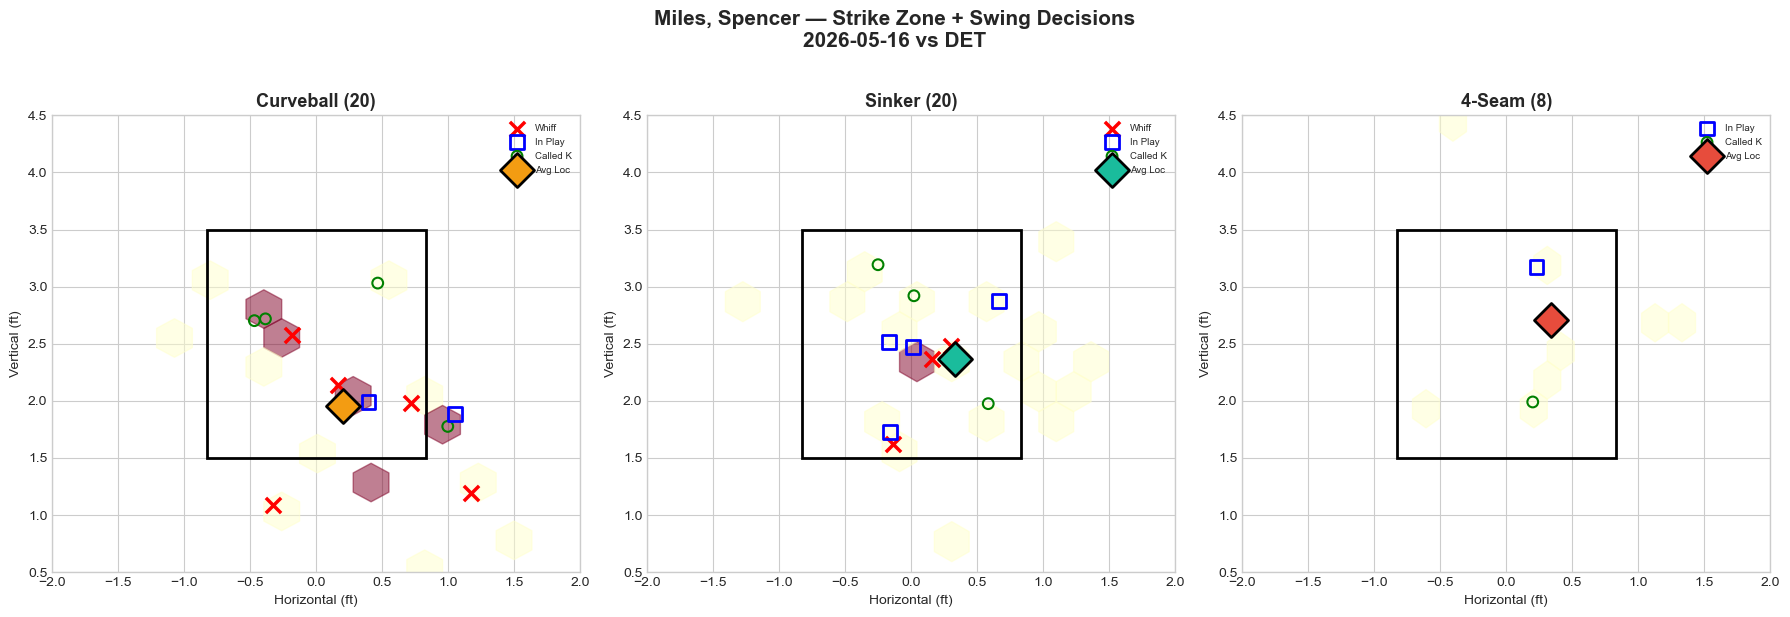

In [7]:
analysis_pitcher = bulk if len(bulk) > 0 else opener
analysis_name = BULK_NAME if len(bulk) > 0 else STARTER_NAME

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
main_pitches = analysis_pitcher['pitch_type'].value_counts().head(3).index.tolist()

for idx, pt in enumerate(main_pitches):
    ax = axes[idx]
    data = analysis_pitcher[analysis_pitcher['pitch_type'] == pt].dropna(subset=['plate_x', 'plate_z'])

    if len(data) > 0:
        ax.hexbin(data['plate_x'], data['plate_z'], gridsize=10, cmap='YlOrRd', mincnt=1, alpha=0.5)

        zone = plt.Rectangle((-0.83, 1.5), 1.66, 2.0, fill=False, edgecolor='black', linewidth=2)
        ax.add_patch(zone)

        whiffs = data[data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])]
        if len(whiffs) > 0:
            ax.scatter(whiffs['plate_x'], whiffs['plate_z'],
                      marker='x', s=120, c='red', linewidths=2.5, zorder=5, label='Whiff')

        in_play_data = data[data['description'].isin(['hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score'])]
        if len(in_play_data) > 0:
            ax.scatter(in_play_data['plate_x'], in_play_data['plate_z'],
                      marker='s', s=100, facecolors='none', edgecolors='blue',
                      linewidths=2, zorder=5, label='In Play')

        called_k = data[data['description'] == 'called_strike']
        if len(called_k) > 0:
            ax.scatter(called_k['plate_x'], called_k['plate_z'],
                      marker='o', s=60, facecolors='none', edgecolors='green',
                      linewidths=1.5, zorder=4, label='Called K')

        avg_x = data['plate_x'].mean()
        avg_z = data['plate_z'].mean()
        ax.scatter(avg_x, avg_z, marker='D', s=300, c=PITCH_COLORS.get(pt, '#95a5a6'),
                  edgecolors='black', linewidths=2, zorder=6, label='Avg Loc')

        ax.set_xlim(-2, 2)
        ax.set_ylim(0.5, 4.5)
        ax.set_title(f'{PITCH_NAMES.get(pt, pt)} ({len(data)})', fontsize=13, fontweight='bold')
        ax.set_xlabel('Horizontal (ft)', fontsize=10)
        ax.set_ylabel('Vertical (ft)', fontsize=10)
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle(f'{analysis_name} — Strike Zone + Swing Decisions\n{GAME_DATE} vs {OPPONENT}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../visualizations/zone_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [8]:
seq_data = analysis_pitcher.dropna(subset=['balls', 'strikes']).copy()
seq_data['count'] = seq_data['balls'].astype(int).astype(str) + '-' + seq_data['strikes'].astype(int).astype(str)

count_groups = {
    'First pitch (0-0)': ['0-0'],
    'Ahead (0-1, 0-2, 1-2)': ['0-1', '0-2', '1-2'],
    'Behind (1-0, 2-0, 3-0, 2-1, 3-1)': ['1-0', '2-0', '3-0', '2-1', '3-1'],
    'Even (1-1, 2-2)': ['1-1', '2-2'],
    'Full count (3-2)': ['3-2']
}

print(f"=== {analysis_name} — Pitch Selection by Count ===\n")

for group_name, counts in count_groups.items():
    group_data = seq_data[seq_data['count'].isin(counts)]
    if len(group_data) > 0:
        mix = group_data['pitch_type'].value_counts(normalize=True).mul(100).round(1)
        print(f"--- {group_name} ({len(group_data)} pitches) ---")
        for pt, pct in mix.items():
            print(f"  {PITCH_NAMES.get(pt, pt)}: {pct}%")
        print()

strikeouts = analysis_pitcher[analysis_pitcher['events'] == 'strikeout']
if len(strikeouts) > 0:
    print(f"=== Strikeout Pitch ({len(strikeouts)} K's) ===")
    print(strikeouts['pitch_type'].value_counts())

=== Miles, Spencer — Pitch Selection by Count ===

--- First pitch (0-0) (15 pitches) ---
  Sinker: 46.7%
  Curveball: 26.7%
  4-Seam: 20.0%
  Slider: 6.7%

--- Ahead (0-1, 0-2, 1-2) (21 pitches) ---
  Curveball: 42.9%
  Slider: 23.8%
  Sinker: 14.3%
  4-Seam: 14.3%
  Changeup: 4.8%

--- Behind (1-0, 2-0, 3-0, 2-1, 3-1) (9 pitches) ---
  Sinker: 66.7%
  Curveball: 22.2%
  4-Seam: 11.1%

--- Even (1-1, 2-2) (10 pitches) ---
  Curveball: 50.0%
  Sinker: 30.0%
  Slider: 10.0%
  4-Seam: 10.0%

--- Full count (3-2) (1 pitches) ---
  Sinker: 100.0%

=== Strikeout Pitch (5 K's) ===
pitch_type
CU    4
SL    1
Name: count, dtype: int64


In [9]:
batter_ids = starter['batter'].unique()

try:
    batter_names_df = playerid_reverse_lookup(batter_ids, key_type='mlbam')
    batter_name_map = dict(zip(
        batter_names_df['key_mlbam'],
        batter_names_df['name_last'] + ', ' + batter_names_df['name_first']
    ))
except:
    batter_name_map = {}

starter_with_names = starter.copy()
starter_with_names['batter_name'] = starter_with_names['batter'].map(batter_name_map)

batter_summary = starter_with_names.groupby('batter_name').agg(
    pitches=('pitch_type', 'count'),
    hits=('events', lambda x: x.isin(['single', 'double', 'triple', 'home_run']).sum()),
    strikeouts=('events', lambda x: (x == 'strikeout').sum()),
    walks=('events', lambda x: (x == 'walk').sum()),
    avg_exit_velo=('launch_speed', lambda x: x.dropna().mean() if len(x.dropna()) > 0 else 0)
).sort_values('pitches', ascending=False)

print(f"=== Top Opposing Batters vs Fluharty + Miles ===\n")
print(batter_summary.head(5).round(1))

print("\n=== Detailed Pitch Breakdown ===\n")
for batter_name in batter_summary.head(3).index:
    batter_data = starter_with_names[starter_with_names['batter_name'] == batter_name]
    print(f"--- {batter_name} ({len(batter_data)} pitches) ---")
    print(f"  Pitches faced: {batter_data['pitch_type'].value_counts().to_dict()}")

    results = batter_data['description'].value_counts()
    whiffs = results.get('swinging_strike', 0) + results.get('swinging_strike_blocked', 0)
    fouls = results.get('foul', 0) + results.get('foul_tip', 0)
    called = results.get('called_strike', 0)
    balls = results.get('ball', 0) + results.get('blocked_ball', 0)
    in_play = results.get('hit_into_play', 0) + results.get('hit_into_play_no_out', 0) + results.get('hit_into_play_score', 0)

    print(f"  Results: {whiffs} whiffs, {fouls} fouls, {called} called strikes, {balls} balls, {in_play} in play")

    events = batter_data['events'].dropna()
    if len(events) > 0:
        print(f"  Outcomes: {events.tolist()}")
    print()

Gathering player lookup table. This may take a moment.
=== Top Opposing Batters vs Fluharty + Miles ===

                    pitches  hits  strikeouts  walks  avg_exit_velo
batter_name                                                        
dingler, dillon          10     0           1      1           93.0
rogers, jake             10     0           1      1            0.0
mcgonigle, kevin          9     1           1      0           88.8
mckinstry, zach           9     1           0      0           71.4
torkelson, spencer        8     0           2      0           79.0

=== Detailed Pitch Breakdown ===

--- dingler, dillon (10 pitches) ---
  Pitches faced: {'FC': 3, 'CU': 3, 'SI': 2, 'CH': 1, 'ST': 1}
  Results: 0 whiffs, 3 fouls, 1 called strikes, 6 balls, 0 in play
  Outcomes: ['strikeout', 'walk']

--- rogers, jake (10 pitches) ---
  Pitches faced: {'SI': 5, 'SL': 2, 'CU': 2, 'FF': 1}
  Results: 1 whiffs, 1 fouls, 3 called strikes, 5 balls, 0 in play
  Outcomes: ['walk', 'strik

Chart saved!


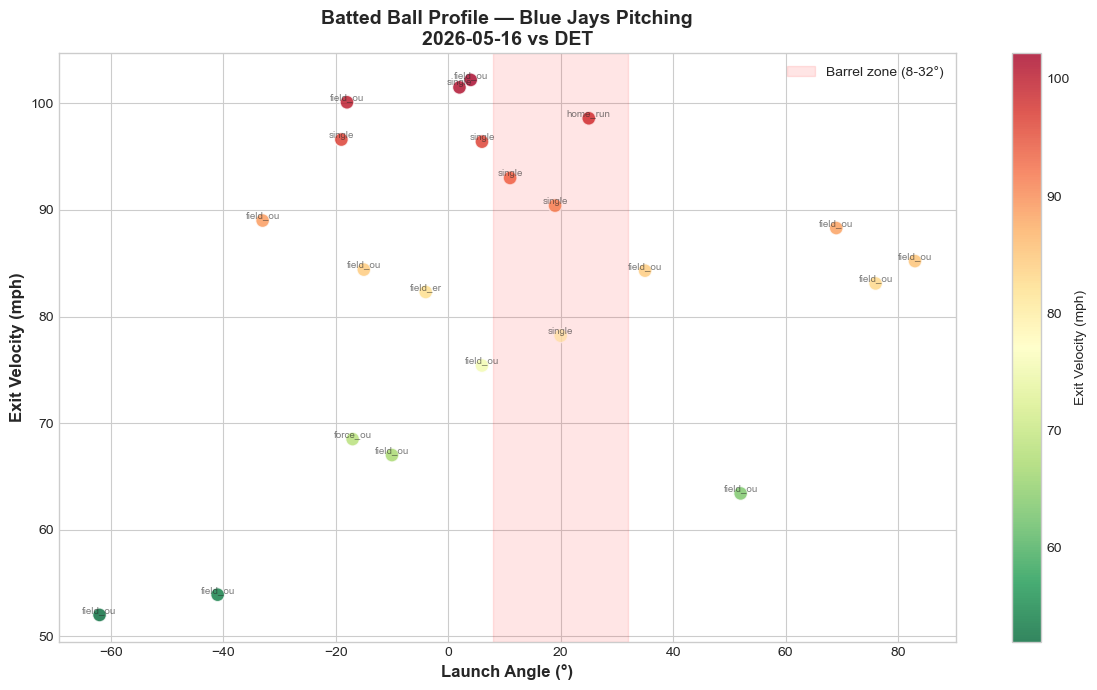


=== Batted Ball Summary ===
Total balls in play: 22
Avg exit velocity: 83.4 mph
Avg launch angle: 8.6°
Hard hit (95+ mph): 6/22 (27%)


In [10]:
in_play = jays_pitchers[jays_pitchers['description'].isin(['hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score'])].dropna(subset=['launch_angle', 'launch_speed'])

if len(in_play) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    scatter = ax.scatter(in_play['launch_angle'], in_play['launch_speed'],
                         c=in_play['launch_speed'], cmap='RdYlGn_r',
                         s=100, edgecolors='white', linewidth=1, alpha=0.8)

    for _, row in in_play.iterrows():
        result = row.get('events', '')
        if pd.notna(result) and result != '':
            ax.annotate(result[:8], xy=(row['launch_angle'], row['launch_speed']),
                        fontsize=7, alpha=0.6, ha='center', va='bottom')

    ax.axvspan(8, 32, alpha=0.1, color='red', label='Barrel zone (8-32°)')
    ax.set_xlabel('Launch Angle (°)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Exit Velocity (mph)', fontsize=12, fontweight='bold')
    ax.set_title(f'Batted Ball Profile — Blue Jays Pitching\n{GAME_DATE} vs {OPPONENT}',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    plt.colorbar(scatter, label='Exit Velocity (mph)')
    plt.tight_layout()
    plt.savefig(f'../visualizations/batted_balls_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

print(f"\n=== Batted Ball Summary ===")
print(f"Total balls in play: {len(in_play)}")
print(f"Avg exit velocity: {in_play['launch_speed'].mean():.1f} mph")
print(f"Avg launch angle: {in_play['launch_angle'].mean():.1f}°")
print(f"Hard hit (95+ mph): {(in_play['launch_speed'] >= 95).sum()}/{len(in_play)} ({(in_play['launch_speed'] >= 95).mean()*100:.0f}%)")

Chart saved!


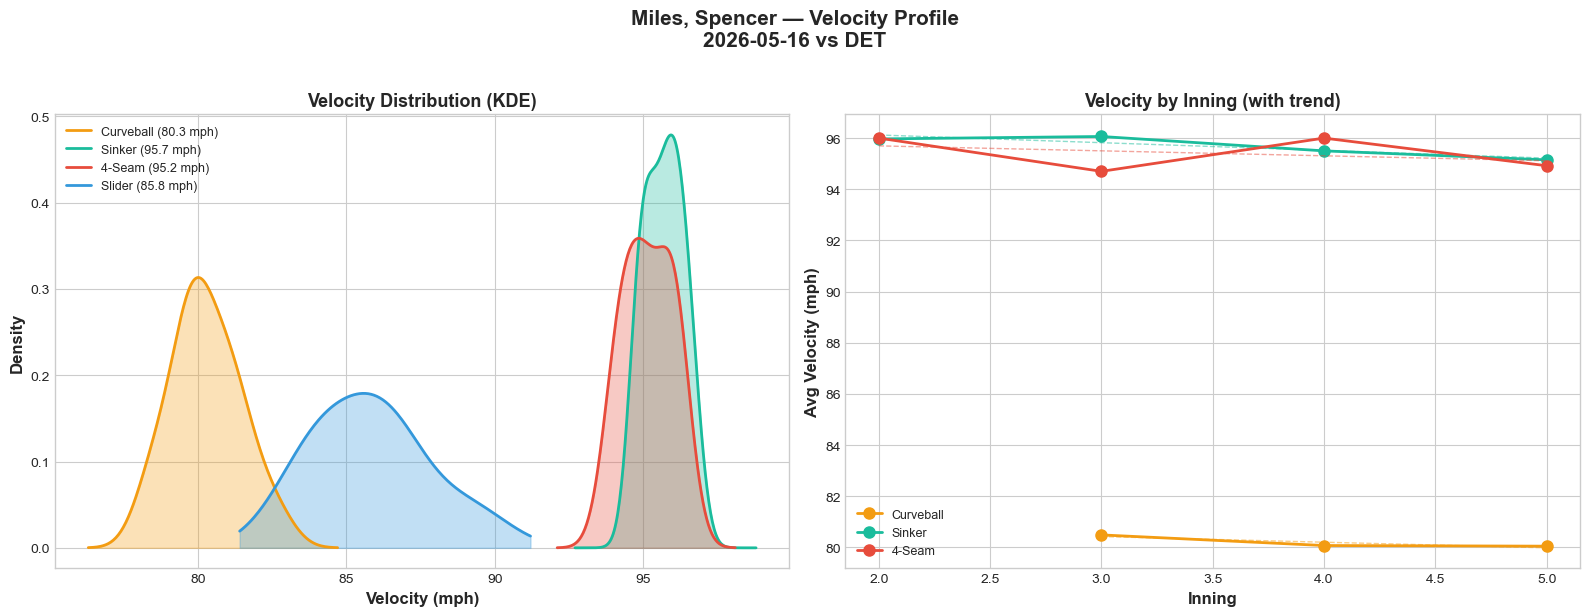

Curveball: 80.5 → 80.0 mph (-0.4 mph change)
Sinker: 96.0 → 95.1 mph (-0.8 mph change)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
for pt in analysis_pitcher['pitch_type'].value_counts().index:
    pt_data = analysis_pitcher[analysis_pitcher['pitch_type'] == pt]['release_speed'].dropna()
    if len(pt_data) >= 3:
        kde = gaussian_kde(pt_data)
        x_range = np.linspace(pt_data.min() - 2, pt_data.max() + 2, 200)
        ax1.fill_between(x_range, kde(x_range), alpha=0.3,
                        color=PITCH_COLORS.get(pt, '#95a5a6'))
        ax1.plot(x_range, kde(x_range),
                color=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=2,
                label=f"{PITCH_NAMES.get(pt, pt)} ({pt_data.mean():.1f} mph)")

ax1.set_xlabel('Velocity (mph)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Velocity Distribution (KDE)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

ax2 = axes[1]
pitcher_inning = analysis_pitcher.dropna(subset=['release_speed']).copy()

for pt in analysis_pitcher['pitch_type'].value_counts().head(3).index:
    pt_data = pitcher_inning[pitcher_inning['pitch_type'] == pt]
    inning_velo = pt_data.groupby('inning')['release_speed'].mean()
    if len(inning_velo) >= 2:
        ax2.plot(inning_velo.index, inning_velo.values, '-o',
                color=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=2, markersize=8,
                label=f"{PITCH_NAMES.get(pt, pt)}")
        z = np.polyfit(inning_velo.index, inning_velo.values, 1)
        trend = np.poly1d(z)
        ax2.plot(inning_velo.index, trend(inning_velo.index), '--',
                color=PITCH_COLORS.get(pt, '#95a5a6'), alpha=0.5, linewidth=1)

ax2.set_xlabel('Inning', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg Velocity (mph)', fontsize=12, fontweight='bold')
ax2.set_title('Velocity by Inning (with trend)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle(f'{analysis_name} — Velocity Profile\n{GAME_DATE} vs {OPPONENT}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../visualizations/velocity_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

for pt in analysis_pitcher['pitch_type'].value_counts().head(2).index:
    pt_data = pitcher_inning[pitcher_inning['pitch_type'] == pt]
    first_inning = pt_data[pt_data['inning'] == pt_data['inning'].min()]['release_speed'].mean()
    last_inning = pt_data[pt_data['inning'] == pt_data['inning'].max()]['release_speed'].mean()
    drop = last_inning - first_inning
    print(f"{PITCH_NAMES.get(pt, pt)}: {first_inning:.1f} → {last_inning:.1f} mph ({drop:+.1f} mph change)")

Chart saved!


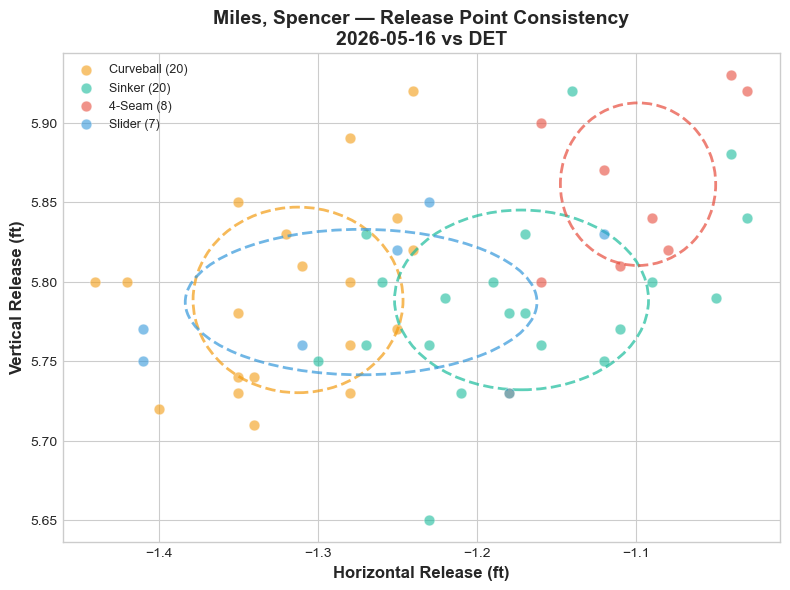


=== Release Point Spread (std dev in inches) ===
  Curveball: H=0.8in, V=0.7in, Total=1.1in 🟢 Tight
  Sinker: H=1.0in, V=0.7in, Total=1.2in 🟢 Tight
  4-Seam: H=0.6in, V=0.6in, Total=0.8in 🟢 Tight
  Slider: H=1.3in, V=0.5in, Total=1.4in 🟢 Tight


In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

for pt in analysis_pitcher['pitch_type'].value_counts().index:
    pt_data = analysis_pitcher[analysis_pitcher['pitch_type'] == pt].dropna(subset=['release_pos_x', 'release_pos_z'])
    if len(pt_data) >= 2:
        ax.scatter(pt_data['release_pos_x'], pt_data['release_pos_z'],
                  c=PITCH_COLORS.get(pt, '#95a5a6'), s=60, alpha=0.6,
                  label=f"{PITCH_NAMES.get(pt, pt)} ({len(pt_data)})",
                  edgecolors='white', linewidth=0.5)

        mean_x = pt_data['release_pos_x'].mean()
        mean_z = pt_data['release_pos_z'].mean()
        std_x = pt_data['release_pos_x'].std()
        std_z = pt_data['release_pos_z'].std()
        if std_x > 0 and std_z > 0:
            ellipse = Ellipse((mean_x, mean_z), std_x*2, std_z*2,
                            fill=False, edgecolor=PITCH_COLORS.get(pt, '#95a5a6'),
                            linewidth=2, linestyle='--', alpha=0.7)
            ax.add_patch(ellipse)

ax.set_xlabel('Horizontal Release (ft)', fontsize=12, fontweight='bold')
ax.set_ylabel('Vertical Release (ft)', fontsize=12, fontweight='bold')
ax.set_title(f'{analysis_name} — Release Point Consistency\n{GAME_DATE} vs {OPPONENT}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'../visualizations/release_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

print("\n=== Release Point Spread (std dev in inches) ===")
for pt in analysis_pitcher['pitch_type'].value_counts().index:
    pt_data = analysis_pitcher[analysis_pitcher['pitch_type'] == pt].dropna(subset=['release_pos_x', 'release_pos_z'])
    if len(pt_data) >= 2:
        h_spread = pt_data['release_pos_x'].std() * 12
        v_spread = pt_data['release_pos_z'].std() * 12
        total = np.sqrt(h_spread**2 + v_spread**2)
        consistency = '🟢 Tight' if total < 3 else ('🟡 Moderate' if total < 5 else '🔴 Inconsistent')
        print(f"  {PITCH_NAMES.get(pt, pt)}: H={h_spread:.1f}in, V={v_spread:.1f}in, Total={total:.1f}in {consistency}")

In [13]:
print(f"=== {analysis_name} — Pitch Tunneling Analysis ===\n")

pitch_types = analysis_pitcher['pitch_type'].value_counts().index.tolist()
tunnel_results = []

for i in range(len(pitch_types)):
    for j in range(i+1, len(pitch_types)):
        pt1, pt2 = pitch_types[i], pitch_types[j]
        d1 = analysis_pitcher[analysis_pitcher['pitch_type'] == pt1].dropna(subset=['release_pos_x', 'release_pos_z', 'plate_x', 'plate_z'])
        d2 = analysis_pitcher[analysis_pitcher['pitch_type'] == pt2].dropna(subset=['release_pos_x', 'release_pos_z', 'plate_x', 'plate_z'])

        if len(d1) >= 3 and len(d2) >= 3:
            rel_diff = np.sqrt(
                (d1['release_pos_x'].mean() - d2['release_pos_x'].mean())**2 +
                (d1['release_pos_z'].mean() - d2['release_pos_z'].mean())**2
            ) * 12

            plate_diff = np.sqrt(
                (d1['plate_x'].mean() - d2['plate_x'].mean())**2 +
                (d1['plate_z'].mean() - d2['plate_z'].mean())**2
            ) * 12

            tunnel_score = plate_diff / rel_diff if rel_diff > 0 else 0
            velo_gap = abs(d1['release_speed'].mean() - d2['release_speed'].mean())

            tunnel_results.append({
                'pair': f"{PITCH_NAMES.get(pt1, pt1)}/{PITCH_NAMES.get(pt2, pt2)}",
                'release_sim': rel_diff,
                'plate_sep': plate_diff,
                'tunnel_score': tunnel_score,
                'velo_gap': velo_gap
            })

if tunnel_results:
    tunnel_df = pd.DataFrame(tunnel_results).sort_values('tunnel_score', ascending=False)
    print(f"{'Pair':<25} {'Release Sim':>12} {'Plate Sep':>11} {'Tunnel':>8} {'Velo Gap':>9}")
    print("-" * 70)
    for _, row in tunnel_df.iterrows():
        grade = '🟢' if row['tunnel_score'] >= 3 else ('🟡' if row['tunnel_score'] >= 1.5 else '🔴')
        print(f"{row['pair']:<25} {row['release_sim']:>10.1f}in {row['plate_sep']:>9.1f}in {grade}{row['tunnel_score']:>5.1f} {row['velo_gap']:>7.1f}mph")

    best = tunnel_df.iloc[0]
    print(f"\n🏆 Best Tunnel: {best['pair']} (score: {best['tunnel_score']:.1f})")

=== Miles, Spencer — Pitch Tunneling Analysis ===

Pair                       Release Sim   Plate Sep   Tunnel  Velo Gap
----------------------------------------------------------------------
Curveball/Slider                 0.5in       8.5in 🟢 17.9     5.5mph
Sinker/Slider                    1.2in       7.6in 🟢  6.3     9.9mph
4-Seam/Slider                    2.3in      10.1in 🟢  4.5     9.3mph
Curveball/4-Seam                 2.7in       9.2in 🟢  3.4    14.9mph
Sinker/4-Seam                    1.2in       4.2in 🟢  3.4     0.5mph
Curveball/Sinker                 1.7in       5.1in 🟢  3.0    15.4mph

🏆 Best Tunnel: Curveball/Slider (score: 17.9)


=== Miles, Spencer — Game Score Analysis ===
Game Score: 56
  Base: 50
  + Outs recorded: +10
  + Bonus K's (after 4th): +2
  - Hits: -4
  - Home runs: -0
  - Walks/HBP: -2
  Rating: 🟡 QUALITY
Chart saved!


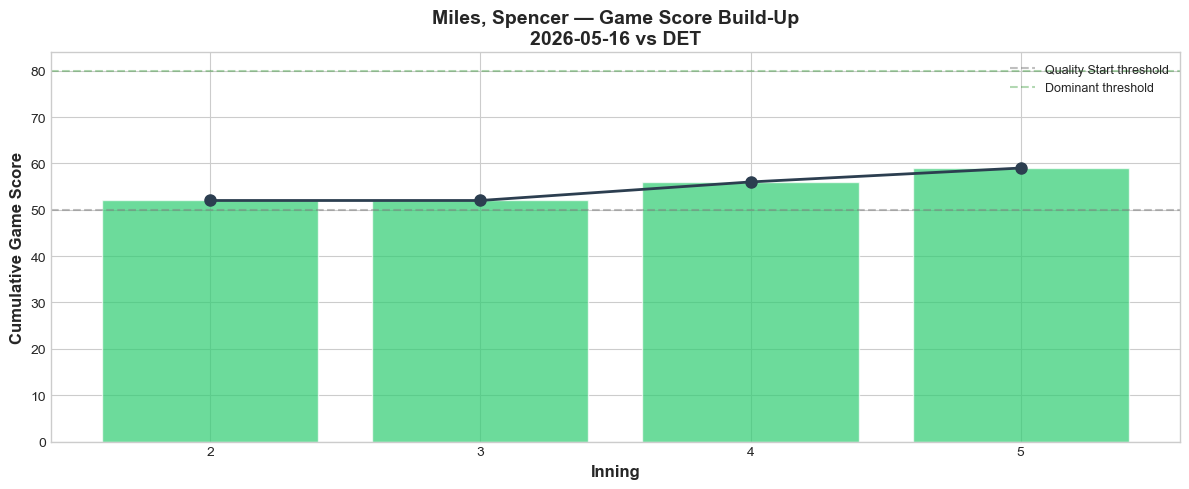

In [14]:
gs_data = analysis_pitcher

total_outs = len(gs_data[gs_data['events'].isin(['strikeout', 'field_out', 'grounded_into_double_play',
                                                   'force_out', 'fielders_choice', 'sac_fly',
                                                   'sac_bunt', 'double_play', 'triple_play',
                                                   'fielders_choice_out'])])
k_count = len(gs_data[gs_data['events'] == 'strikeout'])
hits = len(gs_data[gs_data['events'].isin(['single', 'double', 'triple', 'home_run'])])
walks = len(gs_data[gs_data['events'].isin(['walk', 'hit_by_pitch'])])
hr = len(gs_data[gs_data['events'] == 'home_run'])

game_score = 50 + total_outs - (2 * hits) - (4 * hr) - walks + (2 * max(0, k_count - 4))

print(f"=== {analysis_name} — Game Score Analysis ===")
print(f"Game Score: {game_score}")
print(f"  Base: 50")
print(f"  + Outs recorded: +{total_outs}")
print(f"  + Bonus K's (after 4th): +{2 * max(0, k_count - 4)}")
print(f"  - Hits: -{2 * hits}")
print(f"  - Home runs: -{4 * hr}")
print(f"  - Walks/HBP: -{walks}")

if game_score >= 80: rating = "🟢 DOMINANT"
elif game_score >= 65: rating = "🟢 EXCELLENT"
elif game_score >= 50: rating = "🟡 QUALITY"
elif game_score >= 40: rating = "🟡 AVERAGE"
else: rating = "🔴 POOR"
print(f"  Rating: {rating}")

fig, ax = plt.subplots(figsize=(12, 5))

innings = sorted(gs_data['inning'].unique())
cumulative_score = []
running = 50

for inn in innings:
    inn_data = gs_data[gs_data['inning'] == inn]
    inn_outs = len(inn_data[inn_data['events'].isin(['strikeout', 'field_out', 'grounded_into_double_play',
                                                      'force_out', 'fielders_choice', 'sac_fly',
                                                      'fielders_choice_out'])])
    inn_k = len(inn_data[inn_data['events'] == 'strikeout'])
    inn_hits = len(inn_data[inn_data['events'].isin(['single', 'double', 'triple', 'home_run'])])
    inn_bb = len(inn_data[inn_data['events'].isin(['walk', 'hit_by_pitch'])])
    inn_hr = len(inn_data[inn_data['events'] == 'home_run'])

    running += inn_outs + inn_k - (2 * inn_hits) - (4 * inn_hr) - inn_bb
    cumulative_score.append(running)

colors = ['#2ecc71' if s >= 50 else '#e74c3c' for s in cumulative_score]
ax.bar(innings, cumulative_score, color=colors, alpha=0.7, edgecolor='white')
ax.plot(innings, cumulative_score, '-o', color='#2c3e50', linewidth=2, markersize=8)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Quality Start threshold')
ax.axhline(y=80, color='green', linestyle='--', alpha=0.3, label='Dominant threshold')

ax.set_xlabel('Inning', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Game Score', fontsize=12, fontweight='bold')
ax.set_title(f'{analysis_name} — Game Score Build-Up\n{GAME_DATE} vs {OPPONENT}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(innings)
plt.tight_layout()
plt.savefig(f'../visualizations/gamescore_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Chart saved!


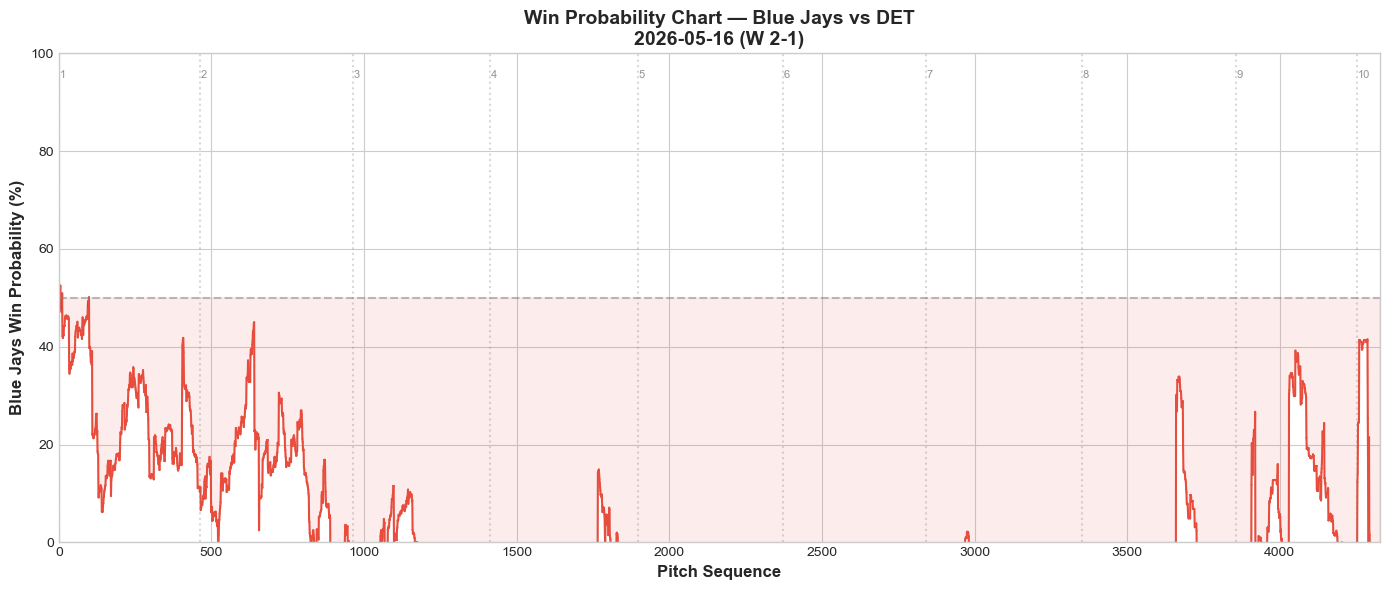


=== Key WPA Moments ===
  📈 Inning 2: Bassitt, Chris — home_run (WP +22.3%)
  📈 Inning 7: Johnson, Pierce — home_run (WP +32.3%)
  📉 Inning 8: Elder, Bryce — home_run (WP +51.2%)
  📈 Inning 9: Fairbanks, Pete — single (WP +39.1%)
  📉 Inning 9: Baker, Bryan — double (WP +39.9%)
  📉 Inning 10: Holton, Tyler — single (WP +25.2%)


In [15]:
wpa_data = game_data.dropna(subset=['delta_home_win_exp']).copy()
wpa_data = wpa_data.sort_values(['inning', 'inning_topbot', 'at_bat_number', 'pitch_number'])

if len(wpa_data) > 0:
    wpa_data['cum_home_wp'] = 0.5 + wpa_data['delta_home_win_exp'].cumsum()
    wpa_data['pitch_seq'] = range(len(wpa_data))

    if HOME_AWAY == 'HOME':
        wpa_data['tor_wp'] = wpa_data['cum_home_wp']
    else:
        wpa_data['tor_wp'] = 1 - wpa_data['cum_home_wp']

    fig, ax = plt.subplots(figsize=(14, 6))

    for i in range(1, len(wpa_data)):
        color = '#134A8E' if wpa_data.iloc[i]['tor_wp'] >= 0.5 else '#e74c3c'
        ax.plot([wpa_data.iloc[i-1]['pitch_seq'], wpa_data.iloc[i]['pitch_seq']],
               [wpa_data.iloc[i-1]['tor_wp'] * 100, wpa_data.iloc[i]['tor_wp'] * 100],
               color=color, linewidth=1.5)

    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(wpa_data['pitch_seq'], wpa_data['tor_wp'] * 100, 50,
                   where=wpa_data['tor_wp'] >= 0.5, alpha=0.1, color='#134A8E')
    ax.fill_between(wpa_data['pitch_seq'], wpa_data['tor_wp'] * 100, 50,
                   where=wpa_data['tor_wp'] < 0.5, alpha=0.1, color='#e74c3c')

    for inn in wpa_data['inning'].unique():
        inn_start = wpa_data[wpa_data['inning'] == inn]['pitch_seq'].min()
        ax.axvline(x=inn_start, color='gray', linestyle=':', alpha=0.3)
        ax.text(inn_start + 2, 95, f'{int(inn)}', fontsize=8, alpha=0.5)

    ax.set_xlabel('Pitch Sequence', fontsize=12, fontweight='bold')
    ax.set_ylabel('Blue Jays Win Probability (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Win Probability Chart — Blue Jays vs {OPPONENT}\n{GAME_DATE} ({RESULT})',
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_xlim(0, len(wpa_data))
    plt.tight_layout()
    plt.savefig(f'../visualizations/wpa_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    print("\n=== Key WPA Moments ===")
    top_moments = wpa_data.nlargest(3, 'delta_home_win_exp')
    bot_moments = wpa_data.nsmallest(3, 'delta_home_win_exp')
    key = pd.concat([top_moments, bot_moments]).sort_values('pitch_seq')
    for _, row in key.iterrows():
        direction = "📈" if row['delta_home_win_exp'] > 0 else "📉"
        wp_change = abs(row['delta_home_win_exp'] * 100)
        player = row.get('player_name', 'Unknown')
        event = row.get('events', row.get('description', ''))
        inning = int(row['inning'])
        print(f"  {direction} Inning {inning}: {player} — {event} (WP {wp_change:+.1f}%)")
else:
    print("WPA data not available for this game.")

Chart saved!


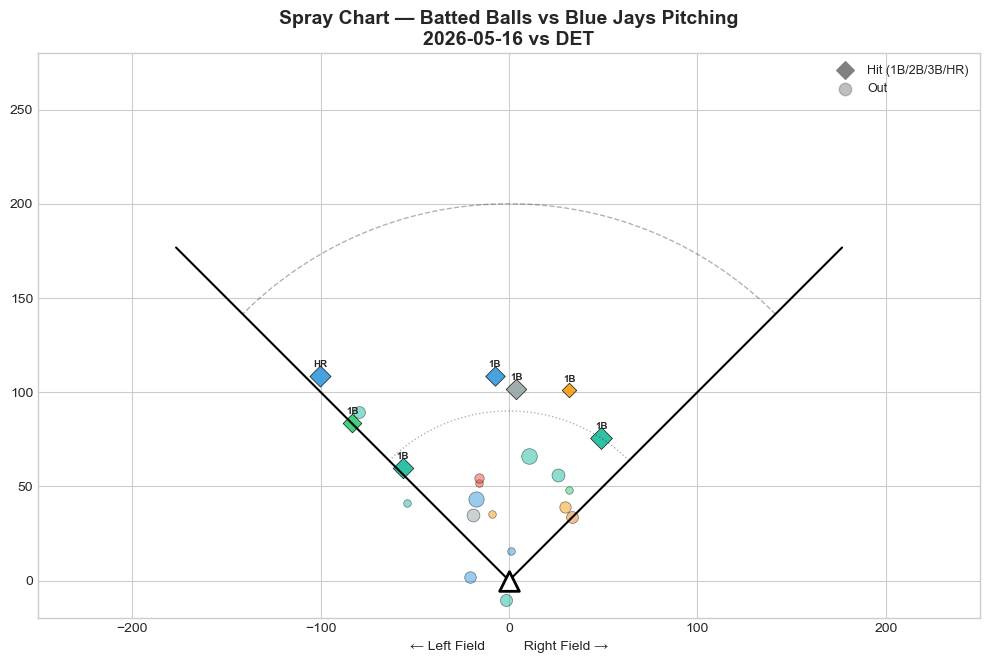


=== Spray Summary ===
Total batted balls tracked: 22
Hits: 7 (32%)
Pull: 4 (18%) | Center: 13 (59%) | Oppo: 5 (23%)


In [17]:
spray_data = jays_pitchers.dropna(subset=['hc_x', 'hc_y']).copy()

if len(spray_data) > 0:
    fig, ax = plt.subplots(figsize=(10, 10))

    spray_data['spray_x'] = spray_data['hc_x'] - 125.42
    spray_data['spray_y'] = 199.58 - spray_data['hc_y']

    theta1 = np.radians(45)
    theta2 = np.radians(135)
    r = 250
    ax.plot([0, r * np.cos(theta1)], [0, r * np.sin(theta1)], 'k-', linewidth=1.5)
    ax.plot([0, r * np.cos(theta2)], [0, r * np.sin(theta2)], 'k-', linewidth=1.5)

    arc_angles = np.linspace(theta1, theta2, 100)
    ax.plot(200 * np.cos(arc_angles), 200 * np.sin(arc_angles), 'k--', alpha=0.3, linewidth=1)
    ax.plot(90 * np.cos(arc_angles), 90 * np.sin(arc_angles), 'k:', alpha=0.3, linewidth=1)

    for _, row in spray_data.iterrows():
        event = row.get('events', '')
        pt = row.get('pitch_type', '')
        ev = row.get('launch_speed', 0)

        color = PITCH_COLORS.get(pt, '#95a5a6')
        if pd.notna(ev):
            size = max(30, min(200, (ev - 60) * 3))
        else:
            size = 50

        if event in ['single', 'double', 'triple', 'home_run']:
            marker = 'D'
            alpha = 0.9
        else:
            marker = 'o'
            alpha = 0.5

        ax.scatter(row['spray_x'], row['spray_y'], c=color, s=size,
                  marker=marker, alpha=alpha, edgecolors='black', linewidth=0.5)

        if event in ['single', 'double', 'triple', 'home_run']:
            label_map = {
                'single': '1B',
                'double': '2B',
                'triple': '3B',
                'home_run': 'HR'
            }
            ax.annotate(label_map.get(event, ''),
                       xy=(row['spray_x'], row['spray_y']),
                       fontsize=7, fontweight='bold', ha='center', va='bottom',
                       xytext=(0, 5), textcoords='offset points')

    ax.scatter(0, 0, marker='^', s=200, c='white', edgecolors='black', linewidth=2, zorder=10)
    ax.set_xlim(-250, 250)
    ax.set_ylim(-20, 280)
    ax.set_aspect('equal')
    ax.set_title(
        'Spray Chart — Batted Balls vs Blue Jays Pitching\n'
        + GAME_DATE + ' vs ' + OPPONENT,
        fontsize=14, fontweight='bold')
    ax.set_xlabel('← Left Field          Right Field →', fontsize=10)

    ax.scatter([], [], marker='D', c='gray', s=80, label='Hit (1B/2B/3B/HR)')
    ax.scatter([], [], marker='o', c='gray', s=80, alpha=0.5, label='Out')
    ax.legend(fontsize=9, loc='upper right')

    plt.tight_layout()
    plt.savefig('../visualizations/spray_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    total_bip = len(spray_data)
    hits_list = ['single', 'double', 'triple', 'home_run']
    hits_count = len(spray_data[spray_data['events'].isin(hits_list)])
    hit_pct = round(hits_count / total_bip * 100)

    print("\n=== Spray Summary ===")
    print("Total batted balls tracked: " + str(total_bip))
    print("Hits: " + str(hits_count) + " (" + str(hit_pct) + "%)")

    pull = spray_data[spray_data['spray_x'] > 30]
    center = spray_data[(spray_data['spray_x'] >= -30) & (spray_data['spray_x'] <= 30)]
    oppo = spray_data[spray_data['spray_x'] < -30]
    pull_pct = round(len(pull) / total_bip * 100)
    center_pct = round(len(center) / total_bip * 100)
    oppo_pct = round(len(oppo) / total_bip * 100)
    print("Pull: " + str(len(pull)) + " (" + str(pull_pct) + "%)"
          + " | Center: " + str(len(center)) + " (" + str(center_pct) + "%)"
          + " | Oppo: " + str(len(oppo)) + " (" + str(oppo_pct) + "%)")
else:
    print("No spray chart data available.")

In [18]:
if SEASON_RS > 0 and SEASON_RA > 0:
    game_rs = int(RESULT.split()[1].split('-')[0]) if 'W' in RESULT else int(RESULT.split()[1].split('-')[1])
    game_ra = int(RESULT.split()[1].split('-')[1]) if 'W' in RESULT else int(RESULT.split()[1].split('-')[0])

    new_rs = SEASON_RS + game_rs
    new_ra = SEASON_RA + game_ra
    new_w = SEASON_W + (1 if 'W' in RESULT else 0)
    new_l = SEASON_L + (1 if 'L' in RESULT else 0)
    total_games = new_w + new_l

    pyth = new_rs**1.83 / (new_rs**1.83 + new_ra**1.83)
    pyth_w = round(pyth * total_games)
    pyth_l = total_games - pyth_w

    actual_pct = new_w / total_games
    pyth_pct = pyth

    fig, ax = plt.subplots(figsize=(12, 5))

    labels = ['Actual', 'Pythagorean']
    wins = [new_w, pyth_w]
    losses = [new_l, pyth_l]

    x = np.arange(len(labels))
    width = 0.35

    bars1 = ax.bar(x - width/2, wins, width, label='Wins', color='#134A8E')
    bars2 = ax.bar(x + width/2, losses, width, label='Losses', color='#e74c3c', alpha=0.7)

    for bar, val in zip(bars1, wins):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
               f'{val}', ha='center', va='bottom', fontweight='bold')
    for bar, val in zip(bars2, losses):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
               f'{val}', ha='center', va='bottom', fontweight='bold')

    ax.set_ylabel('Games', fontsize=12, fontweight='bold')
    ax.set_title(f'Actual vs Pythagorean Record — {GAME_DATE}\nRS: {new_rs} | RA: {new_ra} | Luck: {new_w - pyth_w:+d} wins',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Actual\n({actual_pct:.3f})', f'Pythagorean\n({pyth_pct:.3f})'])
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'../visualizations/pythagorean_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    luck = new_w - pyth_w
    if luck > 0:
        print(f"🍀 Blue Jays are OVERPERFORMING by {luck} wins")
    elif luck < 0:
        print(f"😤 Blue Jays are UNDERPERFORMING by {abs(luck)} wins")
    else:
        print(f"📊 Record matches run differential perfectly")
else:
    print("⚠️ Enter SEASON_RS and SEASON_RA in Cell 1 to enable Pythagorean tracker")

⚠️ Enter SEASON_RS and SEASON_RA in Cell 1 to enable Pythagorean tracker


In [19]:
game_data.to_csv(f'../data/game_{GAME_DATE}.csv', index=False)
print(f"Game data saved: {len(game_data)} pitches")

print(f"\n{'='*60}")
print(f"  REPORT v2.0 COMPLETE — {GAME_DATE} vs {OPPONENT}")
print(f"  Charts saved to ../visualizations/:")
charts = ['movement', 'zone', 'batted_balls', 'velocity', 'release', 'gamescore', 'wpa', 'spray']
for c in charts:
    print(f"    {c}_{GAME_DATE}.png")
if SEASON_RS > 0:
    print(f"    pythagorean_{GAME_DATE}.png")
print(f"{'='*60}")

Game data saved: 4328 pitches

  REPORT v2.0 COMPLETE — 2026-05-16 vs DET
  Charts saved to ../visualizations/:
    movement_2026-05-16.png
    zone_2026-05-16.png
    batted_balls_2026-05-16.png
    velocity_2026-05-16.png
    release_2026-05-16.png
    gamescore_2026-05-16.png
    wpa_2026-05-16.png
    spray_2026-05-16.png
